<a href="https://colab.research.google.com/github/Mariamzoair/Signal-Sampling-Frequency-Analysis-Lab-02-Report/blob/main/Data_Science_Bootcamp_Assignment_Pedestrian_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()


Saving Brooklyn_Bridge_Automated_Pedestrian_Counts_Demonstration_Project.csv to Brooklyn_Bridge_Automated_Pedestrian_Counts_Demonstration_Project.csv


In [5]:
import pandas as pd

fname = list(uploaded.keys())[0]   # automatically uses uploaded file name
df = pd.read_csv(fname)

print("✅ File loaded successfully!")
print("Columns:", df.columns.tolist())
df.head()


✅ File loaded successfully!
Columns: ['hour_beginning', 'location', 'Pedestrians', 'Towards Manhattan', 'Towards Brooklyn', 'weather_summary', 'temperature', 'precipitation', 'lat', 'long', 'events', 'Location1']


,hour_beginning,location,Pedestrians,Towards Manhattan,Towards Brooklyn,weather_summary,temperature,precipitation,lat,long,events,Location1
0,04/30/2019 12:00:00 AM,Brooklyn Bridge,3,3,0,NaN,NaN,NaN,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
1,12/31/2019 10:00:00 PM,Brooklyn Bridge,10,9,1,cloudy,42.0,0.0005,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
2,12/31/2019 11:00:00 PM,Brooklyn Bridge,2,0,2,cloudy,42.0,0.0004,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
3,12/31/2019 09:00:00 PM,Brooklyn Bridge,12,0,12,cloudy,42.0,0.0036,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
4,04/01/2019 03:00:00 AM,Brooklyn Bridge,1,0,1,clear-night,36.0,0.0000,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"


In [6]:
df["hour_beginning"] = pd.to_datetime(
    df["hour_beginning"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

df = df[df["location"].str.strip().str.lower() == "brooklyn bridge"].copy()
df.head()


,hour_beginning,location,Pedestrians,Towards Manhattan,Towards Brooklyn,weather_summary,temperature,precipitation,lat,long,events,Location1
0,2019-04-30 00:00:00,Brooklyn Bridge,3,3,0,NaN,NaN,NaN,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
1,2019-12-31 22:00:00,Brooklyn Bridge,10,9,1,cloudy,42.0,0.0005,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
2,2019-12-31 23:00:00,Brooklyn Bridge,2,0,2,cloudy,42.0,0.0004,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
3,2019-12-31 21:00:00,Brooklyn Bridge,12,0,12,cloudy,42.0,0.0036,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
4,2019-04-01 03:00:00,Brooklyn Bridge,1,0,1,clear-night,36.0,0.0000,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"


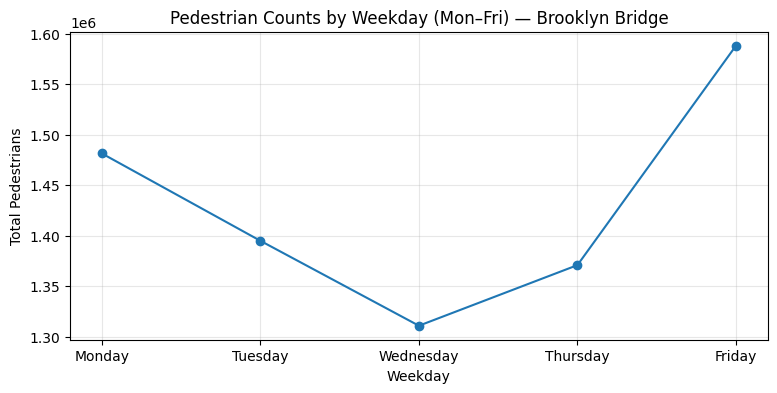

,Pedestrians
Weekday,
Monday,1481435
Tuesday,1394963
Wednesday,1310900
Thursday,1370880
Friday,1588068


In [7]:
import matplotlib.pyplot as plt

# Create weekday column
df["Weekday"] = df["hour_beginning"].dt.day_name()

# Sum pedestrian counts for weekdays only
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
wk = df[df["Weekday"].isin(order)]
weekday_total = wk.groupby("Weekday")["Pedestrians"].sum().reindex(order)

# Plot line graph
plt.figure(figsize=(9,4))
plt.plot(weekday_total.index, weekday_total.values, marker="o")
plt.title("Pedestrian Counts by Weekday (Mon–Fri) — Brooklyn Bridge")
plt.xlabel("Weekday")
plt.ylabel("Total Pedestrians")
plt.grid(True, alpha=0.3)
plt.show()

weekday_total


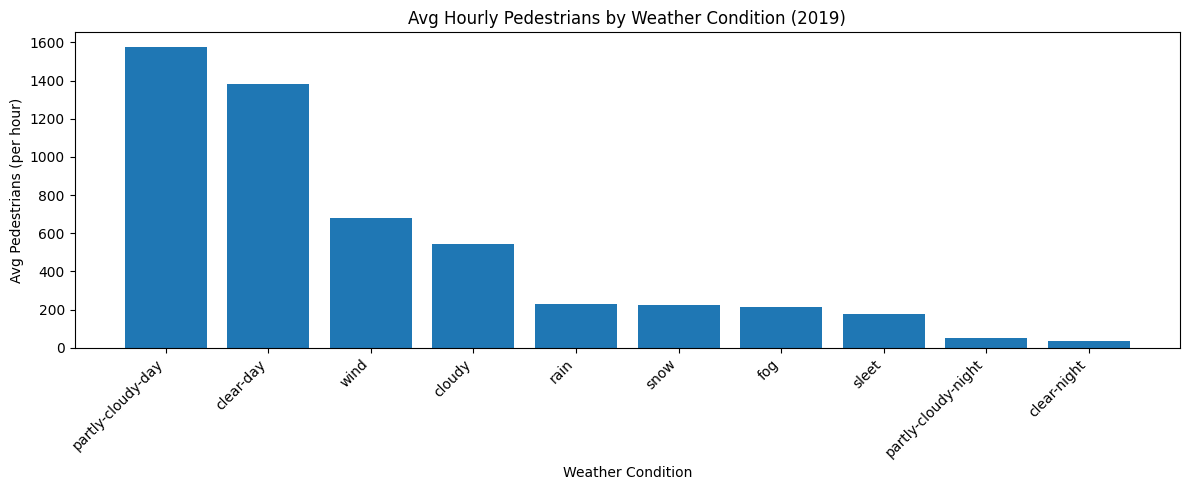

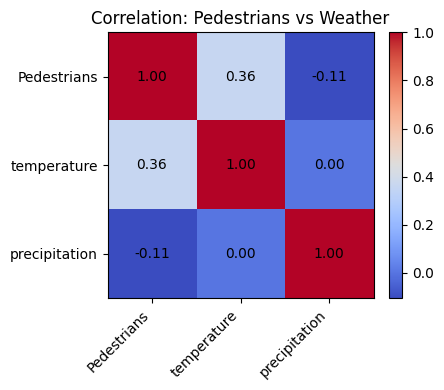

,Pedestrians,temperature,precipitation
Pedestrians,1.000000,0.358757,-0.105432
temperature,0.358757,1.000000,0.001911
precipitation,-0.105432,0.001911,1.000000


In [8]:
# Filter for 2019
df_2019 = df[df["hour_beginning"].dt.year == 2019].copy()

# Average pedestrians by weather condition
weather_avg = (
    df_2019.groupby("weather_summary", dropna=True)["Pedestrians"]
    .mean()
    .sort_values(ascending=False)
)

# Plot bar chart
plt.figure(figsize=(12,5))
plt.bar(weather_avg.index.astype(str), weather_avg.values)
plt.title("Avg Hourly Pedestrians by Weather Condition (2019)")
plt.xlabel("Weather Condition")
plt.ylabel("Avg Pedestrians (per hour)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Correlation matrix
corr_cols = ["Pedestrians", "temperature", "precipitation"]
corr_df = df_2019[corr_cols].apply(pd.to_numeric, errors="coerce").dropna()
corr = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(5,4))
im = plt.imshow(corr.values, interpolation='nearest', cmap="coolwarm")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation: Pedestrians vs Weather")

# Annotate numbers on heatmap
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

corr


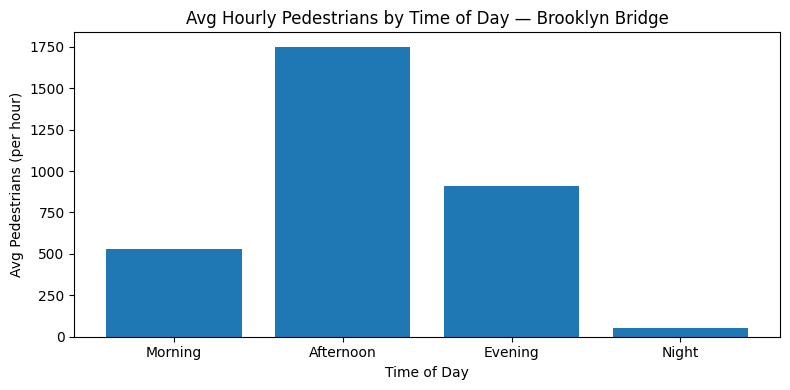

,Pedestrians
TimeOfDay,
Morning,529.699338
Afternoon,1749.484305
Evening,908.873318
Night,50.086680


In [9]:
import numpy as np

# Create hour column
df["hour"] = df["hour_beginning"].dt.hour

# Function to categorize time
def categorize_time(h):
    if pd.isna(h): return np.nan
    h = int(h)
    if 5 <= h < 12:   return "Morning"
    elif 12 <= h < 17:return "Afternoon"
    elif 17 <= h < 21:return "Evening"
    else:             return "Night"

df["TimeOfDay"] = df["hour"].apply(categorize_time)
order_tod = ["Morning", "Afternoon", "Evening", "Night"]

# Average pedestrians per time of day
tod_avg = df.groupby("TimeOfDay")["Pedestrians"].mean().reindex(order_tod)

# Plot bar chart
plt.figure(figsize=(8,4))
plt.bar(tod_avg.index, tod_avg.values)
plt.title("Avg Hourly Pedestrians by Time of Day — Brooklyn Bridge")
plt.xlabel("Time of Day")
plt.ylabel("Avg Pedestrians (per hour)")
plt.tight_layout()
plt.show()

tod_avg
